# ScyllaDB vs MongoDB — Vector Search Benchmark (2048 Dimensions)

**Dataset:** 10M vectors · **2048 dimensions** · COSINE similarity (Bioasq 1024-dim extended via dim_override)
**Workload:** Search Performance Test (VectorDBBench)

### Hardware

| | MongoDB | ScyllaDB |
|---|---|---|
| **Data nodes** | 3 × M20 (4 GB RAM, 2 CPUs, 20 GB) | 3 × i8g.large (16 GB RAM, 2 CPUs, 468 GB) |
| **Search/VS nodes** | 2 × S50 (32 GB RAM, 4 CPUs) | 2 × r7g.xlarge (32 GB RAM, 4 CPUs) |
| **Vectors stored** | 15.3M | 10M |
| **Quantization** | scalar | i8 (scalar) |

**Benchmark client:** r7i.16xlarge (64 CPUs), same region as ScyllaDB Cloud (ScyllaDB 2026.1 + VS 1.5.0)

### Scenarios
| Scenario | Config | k tested |
|---|---|---|
| **ScyllaDB (rescoring)** | oversampling=3.0, rescoring=True, M=64, ef_c=384, ef_s=192 | 100, 10 |
| **ScyllaDB (no rescoring)** | oversampling=10.0, rescoring=False, M=64, ef_c=384, ef_s=192 | 100, 10 |
| **MongoDB** | Atlas S50 search nodes, scalar quantization | 100, 10 |

In [28]:
import matplotlib.pyplot as plt
import numpy as np

CONC_ALL = [1, 5, 10, 20, 30, 40, 60, 80, 100, 120, 150]

# ── ScyllaDB with rescoring (oversampling=3, rescoring=True) ──────────────
scylla_resc_k100 = {
    "conc": CONC_ALL,
    "qps":     [35.64, 110.74, 156.02, 200.11, 215.96, 227.87, 240.90, 248.79, 251.98, 248.54, 253.46],
    "lat_p99": [33.2, 77.1, 114.3, 177.8, 238.5, 298.7, 408.4, 502.3, 637.8, 774.1, 884.9],
    "lat_avg": [28.0, 45.0, 63.9, 99.4, 136.7, 172.3, 241.7, 308.3, 381.8, 459.2, 557.1],
    "recall": 0.9593,
}
scylla_resc_k10 = {
    "conc": CONC_ALL,
    "qps":     [92.87, 439.72, 795.60, 1204.68, 1313.83, 1349.78, 1286.38, 1357.25, 1356.11, 1365.11, 1341.13],
    "lat_p99": [14.4, 15.6, 17.9, 26.6, 38.8, 52.2, 99.5, 108.0, 138.9, 158.9, 214.9],
    "lat_avg": [10.7, 11.3, 12.5, 16.5, 22.7, 29.4, 46.0, 57.7, 71.8, 85.6, 107.0],
    "recall": 0.9597,
}

# ── ScyllaDB without rescoring (oversampling=10, rescoring=False) ─────────
scylla_noresc_k100 = {
    "conc": CONC_ALL,
    "qps":     [33.97, 169.54, 281.29, 312.63, 287.89, 316.83, 319.01, 320.32, 320.94, 315.21, 314.62],
    "lat_p99": [43.9, 43.8, 62.3, 119.0, 227.0, 238.4, 361.7, 464.8, 576.3, 741.3, 914.1],
    "lat_avg": [29.4, 29.4, 35.4, 63.6, 103.5, 125.0, 185.8, 245.4, 305.1, 370.4, 460.1],
    "recall": 0.893,
}
scylla_noresc_k10 = {
    "conc": CONC_ALL,
    "qps":     [105.75, 528.70, 1007.73, 1305.12, 1323.43, 1333.37, 1335.42, 1350.06, 1345.33, 1337.68, 1300.16],
    "lat_p99": [13.2, 13.2, 15.1, 26.5, 41.4, 55.2, 84.2, 111.3, 143.8, 174.2, 238.2],
    "lat_avg": [9.4, 9.4, 9.9, 15.3, 22.5, 29.8, 44.4, 58.3, 73.0, 87.9, 111.3],
    "recall": 0.8675,
}

# ── MongoDB ───────────────────────────────────────────────────────────────
mongo_k100 = {
    "conc":    [1, 10, 100],
    "qps":     [36, 103, 116],
    "lat_p99": [27.0, 90.0, 320.0],
    "recall":  [0.997, 0.985, 0.983],
}
mongo_k10 = {
    "conc":    [1, 10, 100],
    "qps":     [83, 239, 681],
    "lat_p99": [11.8, 40.3, 141.0],
    "recall":  [0.951, 0.953, 0.953],
}

COLORS = {
    "ScyllaDB (rescoring)":    "#6C3FC5",
    "ScyllaDB (no rescoring)": "#B088F9",
    "MongoDB":                 "#00684A",
}

def _style(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

## 1. QPS vs Concurrency

How throughput scales with the number of concurrent search clients.

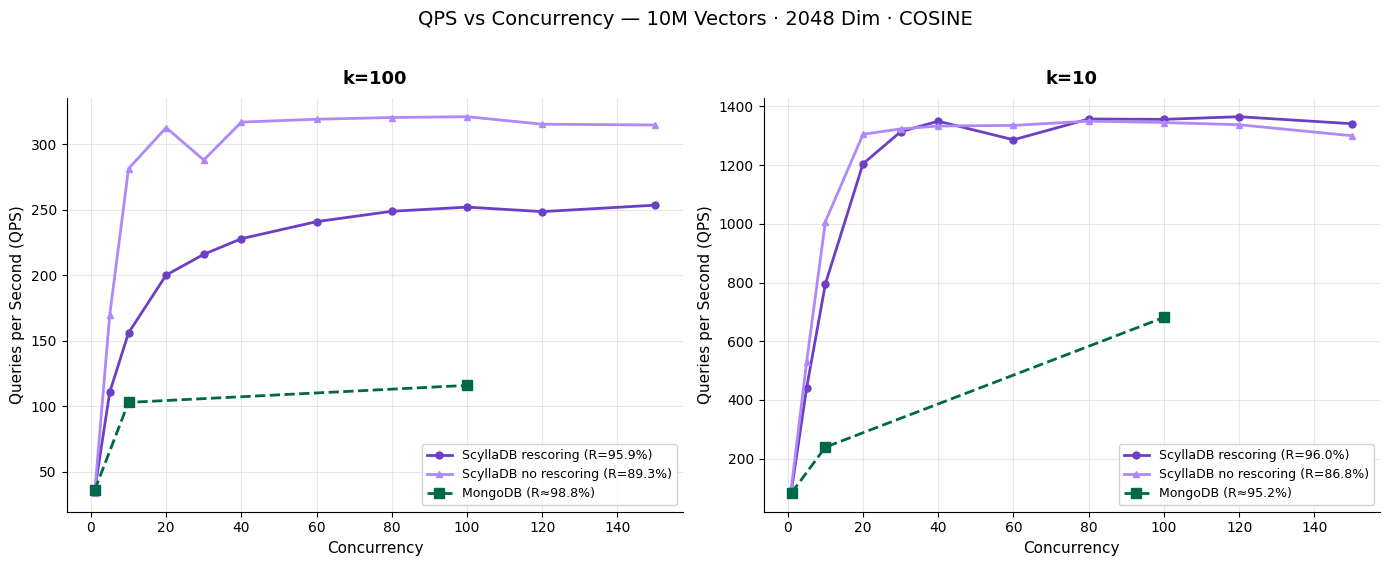

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, k, sr, snr, mg in [
    (ax1, 100, scylla_resc_k100, scylla_noresc_k100, mongo_k100),
    (ax2, 10,  scylla_resc_k10,  scylla_noresc_k10,  mongo_k10),
]:
    ax.plot(sr["conc"], sr["qps"], "o-", color=COLORS["ScyllaDB (rescoring)"],
            label=f'ScyllaDB rescoring (R={sr["recall"]:.1%})', lw=2, ms=5)
    ax.plot(snr["conc"], snr["qps"], "^-", color=COLORS["ScyllaDB (no rescoring)"],
            label=f'ScyllaDB no rescoring (R={snr["recall"]:.1%})', lw=2, ms=5)
    ax.plot(mg["conc"], mg["qps"], "s--", color=COLORS["MongoDB"],
            label=f'MongoDB (R≈{np.mean(mg["recall"]):.1%})', lw=2, ms=7)
    _style(ax, f"k={k}", "Concurrency", "Queries per Second (QPS)")

fig.suptitle("QPS vs Concurrency — 10M Vectors · 2048 Dim · COSINE", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 2. P99 Latency vs Concurrency

Tail latency behavior under increasing load.

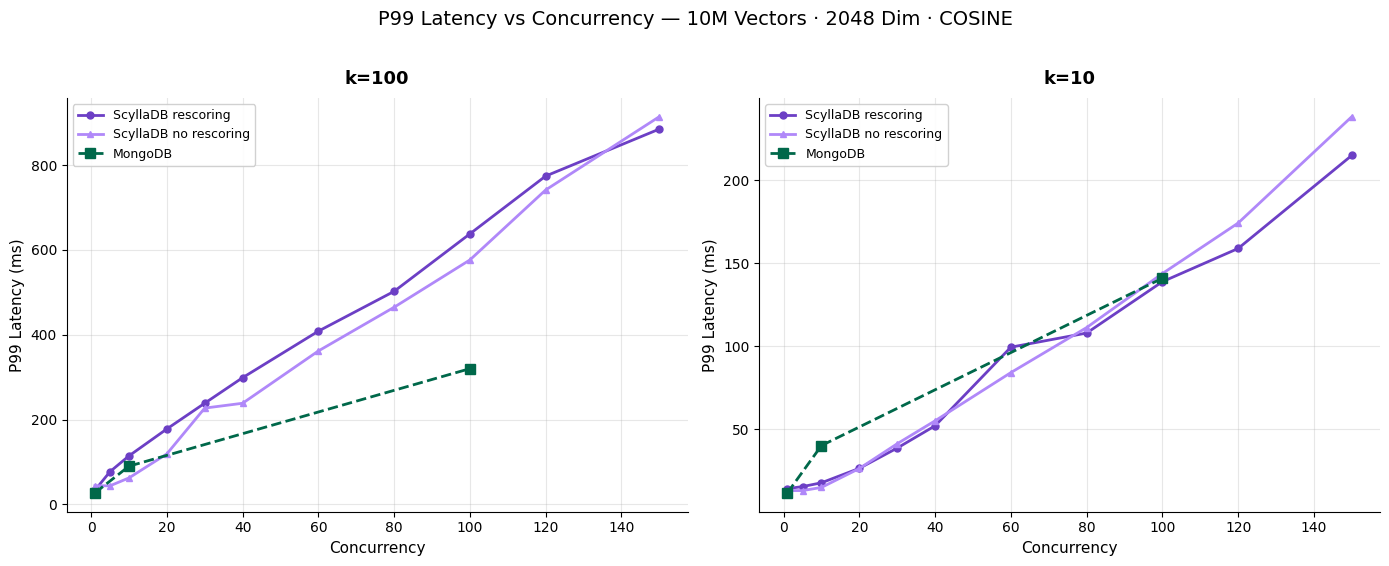

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, k, sr, snr, mg in [
    (ax1, 100, scylla_resc_k100, scylla_noresc_k100, mongo_k100),
    (ax2, 10,  scylla_resc_k10,  scylla_noresc_k10,  mongo_k10),
]:
    ax.plot(sr["conc"], sr["lat_p99"], "o-", color=COLORS["ScyllaDB (rescoring)"],
            label="ScyllaDB rescoring", lw=2, ms=5)
    ax.plot(snr["conc"], snr["lat_p99"], "^-", color=COLORS["ScyllaDB (no rescoring)"],
            label="ScyllaDB no rescoring", lw=2, ms=5)
    ax.plot(mg["conc"], mg["lat_p99"], "s--", color=COLORS["MongoDB"],
            label="MongoDB", lw=2, ms=7)
    _style(ax, f"k={k}", "Concurrency", "P99 Latency (ms)")

fig.suptitle("P99 Latency vs Concurrency — 10M Vectors · 2048 Dim · COSINE", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 3. Peak QPS Comparison

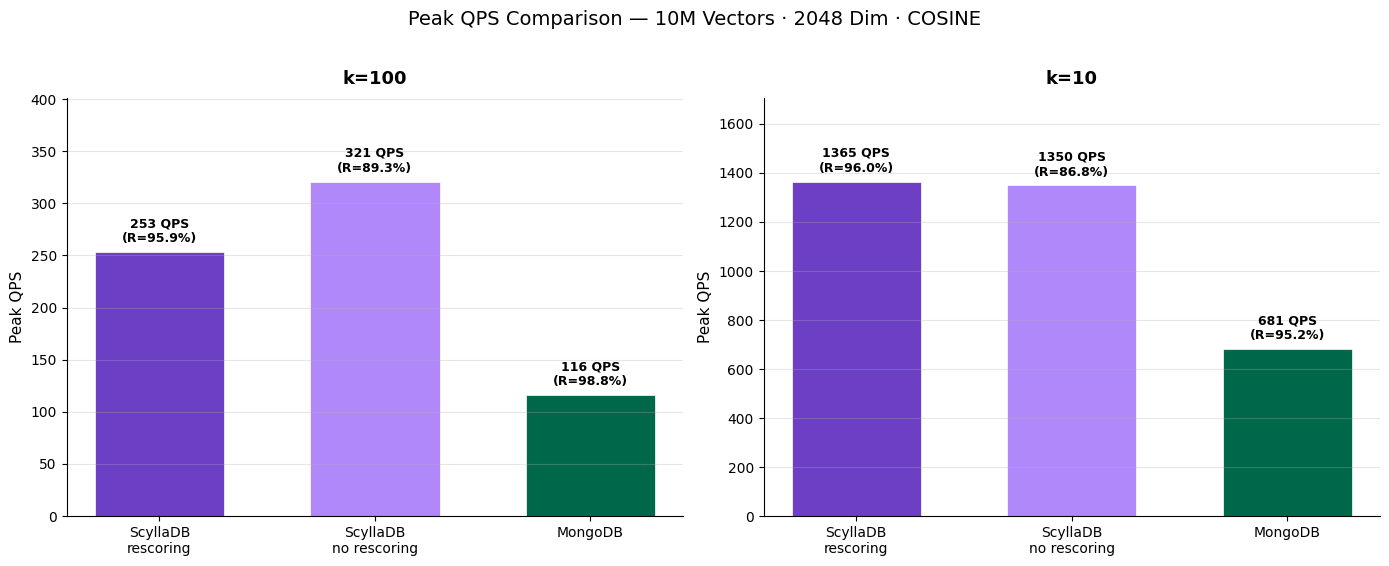

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, k, sr, snr, mg in [
    (ax1, 100, scylla_resc_k100, scylla_noresc_k100, mongo_k100),
    (ax2, 10,  scylla_resc_k10,  scylla_noresc_k10,  mongo_k10),
]:
    categories = ["ScyllaDB\nrescoring", "ScyllaDB\nno rescoring", "MongoDB"]
    peaks = [max(sr["qps"]), max(snr["qps"]), max(mg["qps"])]
    recalls = [sr["recall"], snr["recall"], np.mean(mg["recall"])]
    colors = [COLORS["ScyllaDB (rescoring)"], COLORS["ScyllaDB (no rescoring)"], COLORS["MongoDB"]]

    bars = ax.bar(categories, peaks, color=colors, edgecolor="white", lw=0.5, width=0.6)
    ymax = max(peaks)
    for bar, r in zip(bars, recalls):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + ymax * 0.02,
                f"{bar.get_height():.0f} QPS\n(R={r:.1%})", ha="center", va="bottom",
                fontsize=9, fontweight="bold")
    ax.set_ylim(0, ymax * 1.25)
    ax.set_title(f"k={k}", fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel("Peak QPS", fontsize=11)
    ax.grid(True, alpha=0.3, axis="y")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Peak QPS Comparison — 10M Vectors · 2048 Dim · COSINE",
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 4. QPS vs P99 Latency (Pareto View)

Trade-off between throughput and tail latency. Points closer to the **top-left** corner are better (high QPS, low latency). Concurrency level annotated at key points.

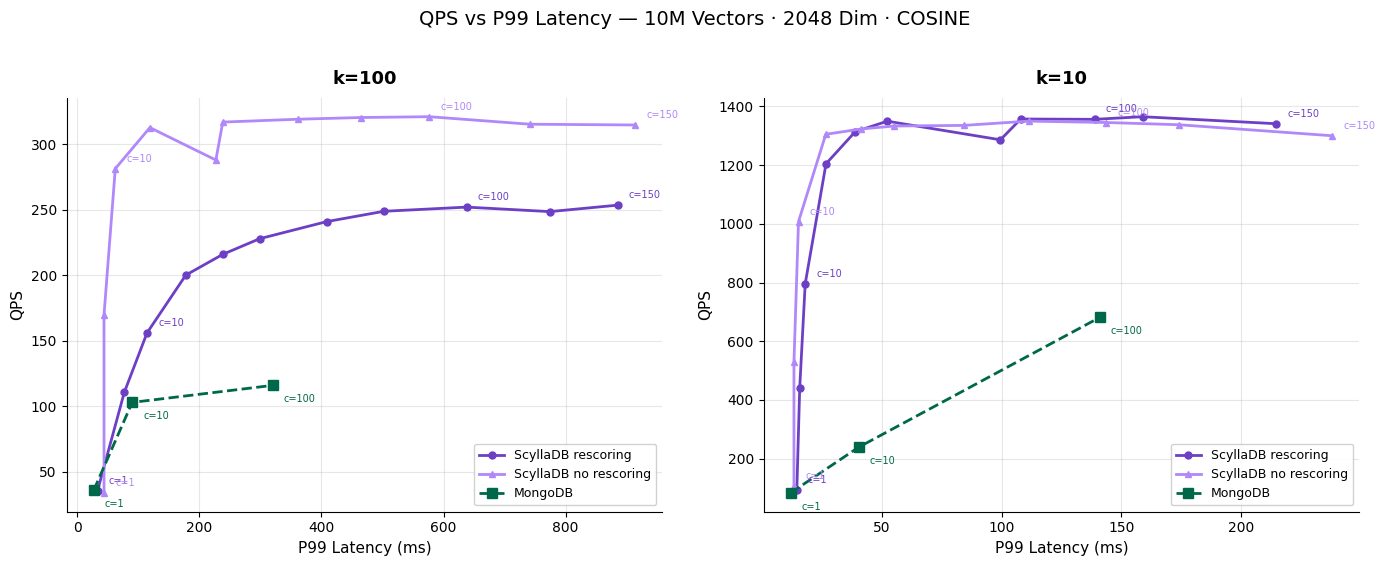

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, k, sr, snr, mg in [
    (ax1, 100, scylla_resc_k100, scylla_noresc_k100, mongo_k100),
    (ax2, 10,  scylla_resc_k10,  scylla_noresc_k10,  mongo_k10),
]:
    ax.plot(sr["lat_p99"], sr["qps"], "o-", color=COLORS["ScyllaDB (rescoring)"],
            label="ScyllaDB rescoring", lw=2, ms=5)
    ax.plot(snr["lat_p99"], snr["qps"], "^-", color=COLORS["ScyllaDB (no rescoring)"],
            label="ScyllaDB no rescoring", lw=2, ms=5)
    ax.plot(mg["lat_p99"], mg["qps"], "s--", color=COLORS["MongoDB"],
            label="MongoDB", lw=2, ms=7)
    # annotate concurrency at key points
    for data, col, pts in [
        (sr,  COLORS["ScyllaDB (rescoring)"],    (1, 10, 100, 150)),
        (snr, COLORS["ScyllaDB (no rescoring)"], (1, 10, 100, 150)),
    ]:
        for i, c in enumerate(data["conc"]):
            if c in pts:
                ax.annotate(f"c={c}", (data["lat_p99"][i], data["qps"][i]),
                            textcoords="offset points", xytext=(8, 5), fontsize=7, color=col)
    for i, c in enumerate(mg["conc"]):
        ax.annotate(f"c={c}", (mg["lat_p99"][i], mg["qps"][i]),
                    textcoords="offset points", xytext=(8, -12), fontsize=7, color=COLORS["MongoDB"])
    _style(ax, f"k={k}", "P99 Latency (ms)", "QPS")

fig.suptitle("QPS vs P99 Latency — 10M Vectors · 2048 Dim · COSINE", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 5. Summary

### k=100

| Metric | ScyllaDB (rescoring) | ScyllaDB (no rescoring) | MongoDB |
|---|---|---|---|
| **Peak QPS** | 253 (c=150) | 321 (c=100) | 116 (c=100) |
| **QPS @ c=10** | 156 | 281 | 103 |
| **P99 Latency @ c=1** | 33.2 ms | 43.9 ms | 27.0 ms |
| **P99 Latency @ c=100** | 637.8 ms | 576.3 ms | 320.0 ms |
| **Recall** | 95.9% | 89.3% | ~98.8% |

### k=10

| Metric | ScyllaDB (rescoring) | ScyllaDB (no rescoring) | MongoDB |
|---|---|---|---|
| **Peak QPS** | 1,365 (c=120) | 1,350 (c=80) | 681 (c=100) |
| **QPS @ c=10** | 796 | 1,008 | 239 |
| **P99 Latency @ c=1** | 14.4 ms | 13.2 ms | 11.8 ms |
| **P99 Latency @ c=100** | 138.9 ms | 143.8 ms | 141.0 ms |
| **Recall** | 96.0% | 86.8% | ~95.2% |

### Key observations
- **k=100:** ScyllaDB with rescoring achieves **2.2× higher peak QPS** than MongoDB (253 vs 116) at comparable recall (~96%); no-rescoring pushes to **2.8×** (321 vs 116) but recall drops to 89.3%
- **k=10:** ScyllaDB dominates — **2.0× peak QPS** with rescoring (1,365 vs 681) at similar recall; no-rescoring is comparable at 1,350 QPS but lower recall (86.8%)
- **Rescoring trade-off:** Rescoring yields ~7% higher recall at k=100 with ~21% lower peak QPS; at k=10 the QPS difference is negligible
- **Latency:** At low concurrency (c=1), all three scenarios show comparable P99 latencies (11–44 ms); MongoDB maintains lower tail latency at high concurrency for k=100
- **Scaling:** ScyllaDB throughput scales smoothly up to c=150; MongoDB was tested up to c=100